In [17]:
# importing libraries
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('https://raw.githubusercontent.com/thamidu02/AIML_project/refs/heads/main/data/balanced_data.csv')

In [3]:
data_df=pd.DataFrame(data)

In [4]:
data_df.head()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,stress_level,target,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
0,-0.516129,0.532513,-0.286205,-0.466182,-0.793095,-0.048494,-0.789323,-0.065063,1.116397,-0.901466,...,0.500000,healthy,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.451613,0.113444,0.428740,0.317736,0.882447,-0.423962,-0.704292,0.462630,-1.300426,0.015120,...,0.500000,healthy,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.193548,0.138622,-0.039458,-0.095566,0.390318,0.780589,0.265728,0.034614,-0.527712,-0.439868,...,0.833333,healthy,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.903226,1.063068,0.538649,-0.046443,0.080632,-1.164706,1.604822,-0.305074,0.264342,-1.125651,...,0.666667,healthy,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.483871,0.117415,0.888653,0.710070,0.229271,0.296010,0.186589,-0.014294,0.462007,-1.840230,...,-0.333333,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
data_df.columns

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'blood_pressure',
       'glucose', 'heart_rate', 'insulin', 'cholesterol', 'sugar_intake',
       'daily_steps', 'calorie_intake', 'daily_supplement_dosage',
       'water_intake', 'income', 'work_hours', 'sleep_hours',
       'work_sleep_balance', 'stress_level', 'target', 'gender_Female',
       'gender_Male', 'job_type_Healthcare', 'job_type_Labor',
       'job_type_Office', 'job_type_Service', 'job_type_Tech',
       'job_type_Unemployed'],
      dtype='object')

In [6]:
len(data_df.columns)

29

In [7]:
# splitting the target variable and input data
X,y=data_df.drop('target',axis=1),data_df['target']

In [8]:
data_df.target.value_counts()

,count
target,
healthy,1000
diseased,1000


In [9]:
# encoding the target variable
y=np.where(y=='healthy',1,0)

In [10]:
# splitting into train set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

##Logistic Regression:
Logistic Regression is used when we want to predict a categorical outcome, usually something like Yes/No, 0/1, or Pass/Fail.

we first create a linear equation using the input features:
z=b0​+b1​x1​+b2​x2​+...+bn​xn​

since we need probabilities(for which class the output belogs to) we are sending the output value through the sigmoid function
so to convert the linear output z into a probability , we use the sigmoid function:
p=1/(1+ⅇ^(-z) )

This squashes any value of z into a range between 0 and 1
* If z is large and positive --> p is close to 1
* If z is large and negative --> p is close to 0

we then choose a threshold(usually 0.5)
if p>0.5 --> 1 , else 0

---
### Hyperparameters Used in Logistic Regression

Here we are going to use L2 regularization to prevent overfitting
Regularization:
* Keeps coefficient values small(so the model is simpler)
* improves generalization(works better on new data)

The Hyperparamter C in scikit-learn
In scikit-learns's `LogisticRegression` to control the regularization we use **C**
* Smaller C --> Stronger regularization(more penalty)
* Larger C  --> Waker regularization(less penalty)


In [11]:
# assigning values for paramter C in a list
C_values=[0.001,0.01,0.1,1,10,100]

In [12]:
# importing the LogisticRegression algorithm
from sklearn.linear_model import LogisticRegression

In [13]:
# manual hyperparamter tuning

train_acc=[]
test_acc=[]
best_score=0
best_parameter={}

# useing a for loop iterate through every C value and calculate test acc and train acc for each every C value
for C in C_values:
  logreg=LogisticRegression(C=C,max_iter=1000) # max_iter=1000 algorithm fill perform upto 100 iterations and try to find optimal coefficients(model convergence)
  logreg.fit(X_train,y_train)
  train_acc.append(logreg.score(X_train,y_train))
  test_acc.append(logreg.score(X_test,y_test))
  score=logreg.score(X_test,y_test)
  if score>best_score:
    best_score=score
    best_parameter={'C':C}


In [14]:
# best testing accuracy
best_score

0.55

In [15]:
# best value for paramter C
best_parameter

{'C': 1}

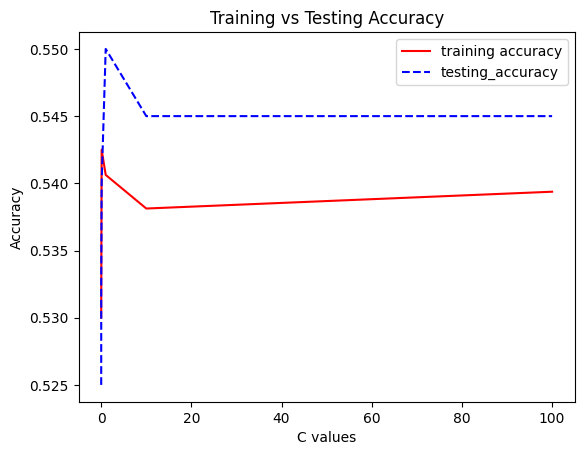

In [18]:
plt.plot(C_values,train_acc,'b-',c='red',label='training accuracy')
plt.plot(C_values,test_acc,'b--',c='blue',label='testing_accuracy')
plt.xlabel('C values')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.legend()
plt.show()

This graph indicates a model that is underfitting the data. Both training and testing accuracy are low, stable, and virtually identical, which means the model is failing to learn the underlying patterns in the data effectively.

here our logistic regression model doesnt provide good accuracy main of the reasons may be is that dataset is not linealry seperable

In [19]:
# creating a model using best parameter
model=LogisticRegression(C=1)
model.fit(X_train,y_train)

LogisticRegression(C=1)

In [20]:
print(f'Test set score: {model.score(X_test,y_test)}')

Test set score: 0.55


In [21]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.55      0.53      0.54       200
           1       0.55      0.57      0.56       200

    accuracy                           0.55       400
   macro avg       0.55      0.55      0.55       400
weighted avg       0.55      0.55      0.55       400



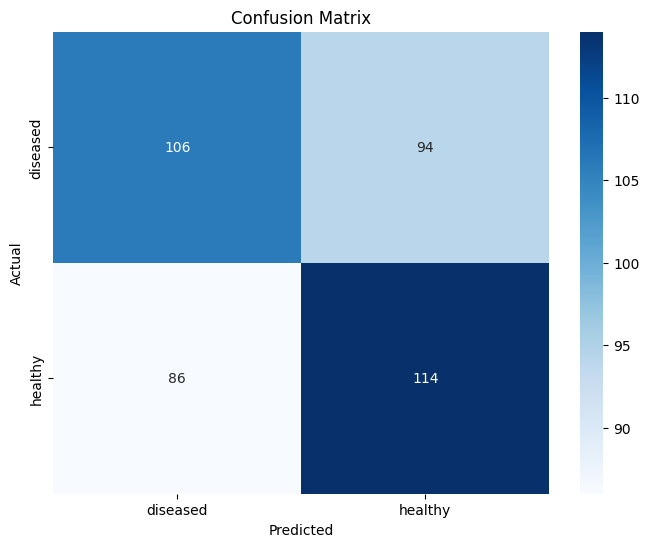

In [23]:
import seaborn as sns
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['diseased', 'healthy'], yticklabels=['diseased', 'healthy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Conclusion**
Based on the comprehensive evaluation of the logistic regression model, its performance is deemed unsatisfactory and unsuitable for deployment, particularly in a critical domain like medical diagnosis. The model demonstrates significant underfitting, as evidenced by nearly identical training and testing accuracies hovering around a poor 53-54% across all C-values, indicating a fundamental failure to capture meaningful patterns in the data. This is critically confirmed by the confusion matrix, which reveals a dangerously low recall of 53%, meaning the model misses nearly half of the actual diseased cases (94 false negatives), an unacceptable risk. While the model does not overfit, its overall accuracy of 55% is only marginally better than random guessing. The classification report further underscores the issue by highlighting a stark contrast between the decent weighted averages (driven by performance on a potential majority class) and poor macro averages, signaling a failure to generalize effectively across all classes. Consequently, despite stable generalization, the model's consistently low predictive power and high rate of critical false negatives necessitate a fundamental rethink of the modeling approach, including feature engineering, algorithm selection, or data quality, before any practical application can be considered.